Import libraries


In [ ]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [ ]:
%time train_df = pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/val_men.csv")

CPU times: user 20.9 ms, sys: 8.01 ms, total: 28.9 ms
Wall time: 28.7 ms
CPU times: user 13.5 ms, sys: 2 ms, total: 15.4 ms
Wall time: 15.4 ms
CPU times: user 4.55 ms, sys: 0 ns, total: 4.55 ms
Wall time: 4.56 ms


In [ ]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['conversion']
treatment_feature = ['treatment']

In [ ]:
X_train = train_df[in_features].values.astype(float) # type: ignore
y_train = train_df[label_feature].values.astype(float) # type: ignore
t_train = train_df[treatment_feature].values.astype(float) # type: ignore

X_test = test_df[in_features].values.astype(float) # type: ignore
y_test = test_df[label_feature].values.astype(float) # type: ignore
t_test = test_df[treatment_feature].values.astype(float) # type: ignore

X_val = val_df[in_features].values.astype(float) # type: ignore
y_val = val_df[label_feature].values.astype(float) # type: ignore
t_val = val_df[treatment_feature].values.astype(float) # type: ignore

In [ ]:
print('X_train[:10]', X_train[:1].astype(float))

X_train[:10] [[-0.21435131  1.6331766   1.0667411   0.90252386 -1.1010233   1.07039981
   1.00043033  2.70003843 -0.88552759 -0.88616046]]


In [ ]:
print('y_train[:10]', y_train[:10].astype(float))

y_train[:10] [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [ ]:
# Transform to tensor
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

x_men_train_t = to_tensor(X_train)
x_men_val_t = to_tensor(X_val)
x_men_test_t = to_tensor(X_test)

y_men_train_t = to_tensor(y_train).reshape(-1, 1)
y_men_val_t = to_tensor(y_val).reshape(-1, 1)
y_men_test_t = to_tensor(y_test).reshape(-1, 1)

# t_train/t_val/t_test cũng tương tự
t_men_train_t = to_tensor(t_train.astype(float)).reshape(-1, 1)
t_men_val_t = to_tensor(t_val.astype(float)).reshape(-1, 1)
t_men_test_t = to_tensor(t_test.astype(float)).reshape(-1, 1)

# Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 6400
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)

print("-------------------------------------------------------------")
print("✅ Completed transform to tensor ✅")
print(f"Shape of train: x={x_men_train_t.shape}; y={y_men_train_t.shape}; t={t_men_train_t.shape}")
print(f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print(f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅ Completed transform to tensor ✅
Shape of train: x=torch.Size([25567, 10]); y=torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


In [ ]:
epochs = 50
lr = 1e-4
wd = 1e-5
early_stop_metric = "qini"
ema = True
ema_alpha = 0.15
patience = 10
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start = 0
print (f" epochs = {epochs}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")
print (f" early stop start = {early_stop_start}")

 epochs = 50
 learning rate = 0.001
 weight decay = 1e-05
 early stop = qini
 use ema = True
 ema alpha = 0.15
 patience = 10
 shared hidden = 200
 outcome hidden = 100
 early stop start = 0


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 1.3254 | Val Loss: 1.2961 | Val Qini: 0.2106 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2106 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 1.1505 | Val Loss: 1.0684 | Val Qini: 0.2765 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2205 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Loss: 0.6692 | Val Loss: 0.5087 | Val Qini: 0.7475 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2995 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/50 | Loss: 0.1550 | Val Loss: 0.1282 | Val Qini: 0.6415 ✓ above trend but not peak (patience: 1/10)EMA Trend: 0.3508 | ✓ above trend but not peak (patience: 1/10)
Epoch 5/50 | Loss: 0.1515 | Val Loss: 0.1819 | Val Qini: 0.6457 ✓ above trend but not peak (patience: 2/10)EMA Trend: 0.3951 | ✓ above tren

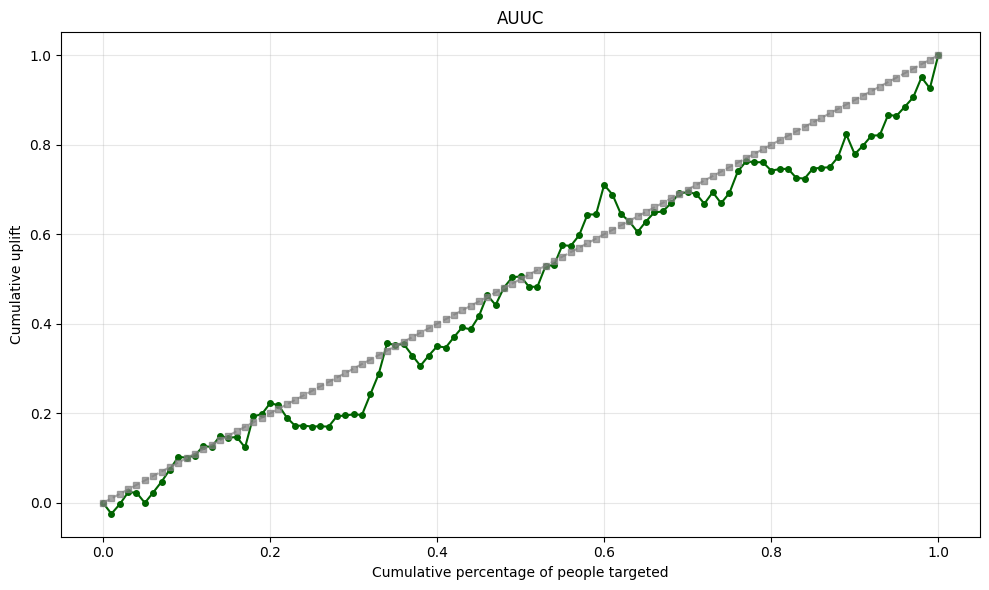

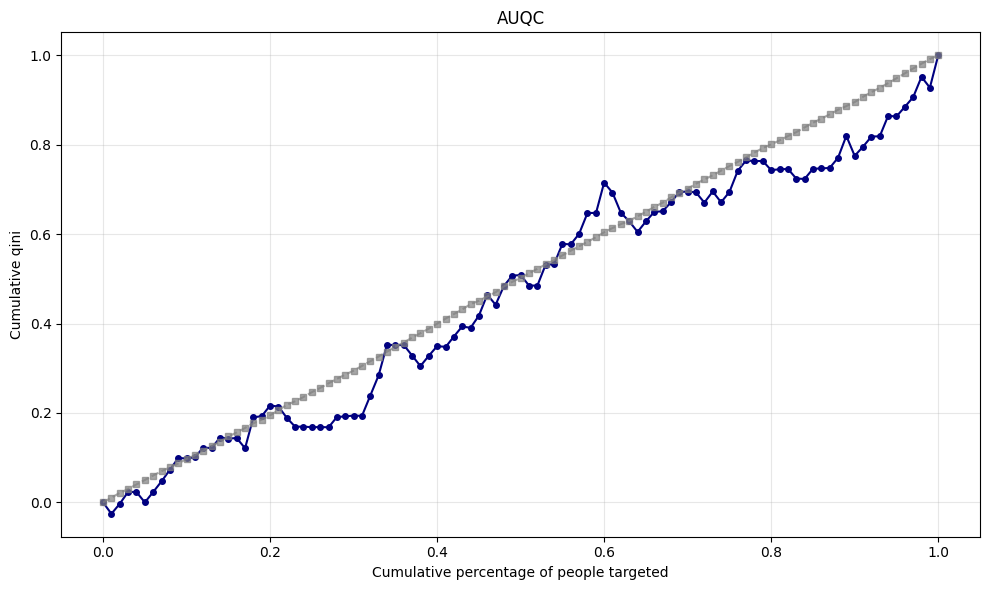

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.466
AUQC: 0.465
Lift: 0.004
KRCC: 0.001
ATE (predicted): -0.0744
ATE (true): 0.0067
ATE error: 0.0811


In [ ]:
seed = 412312
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 1.3343 | Val Loss: 1.2858 | Val Qini: 0.6618 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6618 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 1.0215 | Val Loss: 0.8769 | Val Qini: 0.7220 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6708 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Loss: 0.3544 | Val Loss: 0.2253 | Val Qini: 0.2588 (patience: 1/10)EMA Trend: 0.6090 | (patience: 1/10)
Epoch 4/50 | Loss: 0.1102 | Val Loss: 0.1357 | Val Qini: 0.2689 (patience: 2/10)EMA Trend: 0.5580 | (patience: 2/10)
Epoch 5/50 | Loss: 0.2238 | Val Loss: 0.2071 | Val Qini: 0.2906 (patience: 3/10)EMA Trend: 0.5179 | (patience: 3/10)
Epoch 6/50 | Loss: 0.1632 | Val Loss: 0.2055 | Val Qini: 0.3266 (patience: 4/10)EMA Trend: 0.4892 

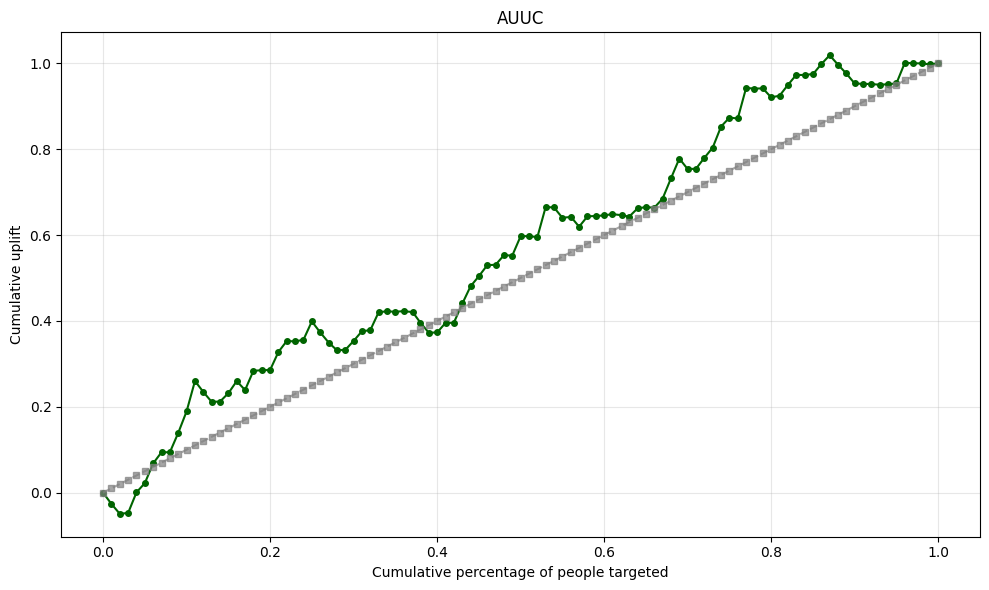

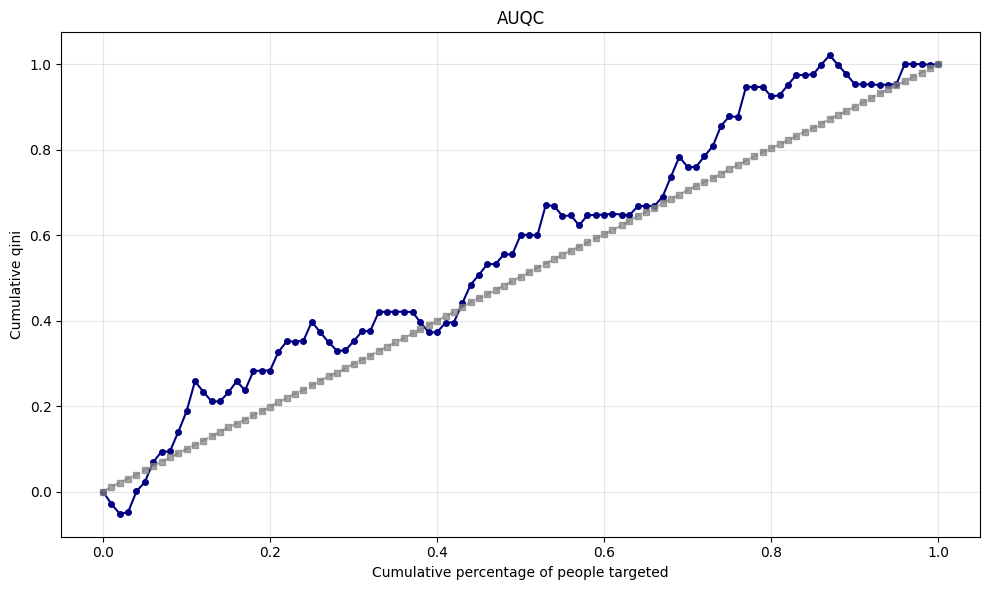

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.564
AUQC: 0.565
Lift: 0.008
KRCC: 0.058
ATE (predicted): 0.0616
ATE (true): 0.0067
ATE error: 0.0549


In [ ]:
seed = 42
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 1.2739 | Val Loss: 1.2165 | Val Qini: 0.4537 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.4537 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 0.9056 | Val Loss: 0.7429 | Val Qini: 0.2617 (patience: 1/10)EMA Trend: 0.4249 | (patience: 1/10)
Epoch 3/50 | Loss: 0.2451 | Val Loss: 0.1547 | Val Qini: 0.2435 (patience: 2/10)EMA Trend: 0.3977 | (patience: 2/10)
Epoch 4/50 | Loss: 0.1197 | Val Loss: 0.1517 | Val Qini: 0.2627 (patience: 3/10)EMA Trend: 0.3774 | (patience: 3/10)
Epoch 5/50 | Loss: 0.2117 | Val Loss: 0.2091 | Val Qini: 0.3075 (patience: 4/10)EMA Trend: 0.3669 | (patience: 4/10)
Epoch 6/50 | Loss: 0.2447 | Val Loss: 0.1957 | Val Qini: 0.3754 ✓ above trend but not peak (patience: 5/10)EMA Tre

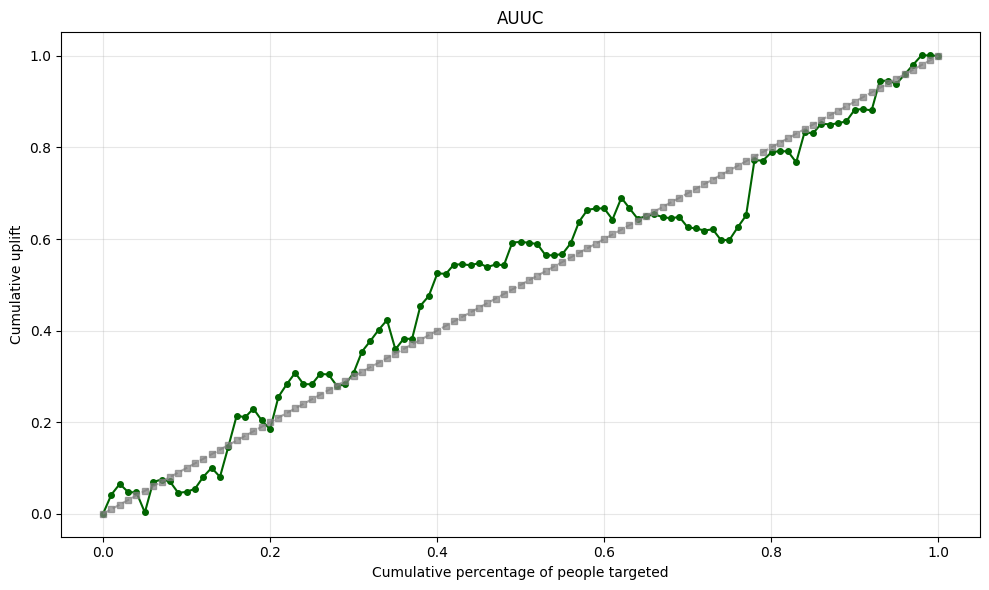

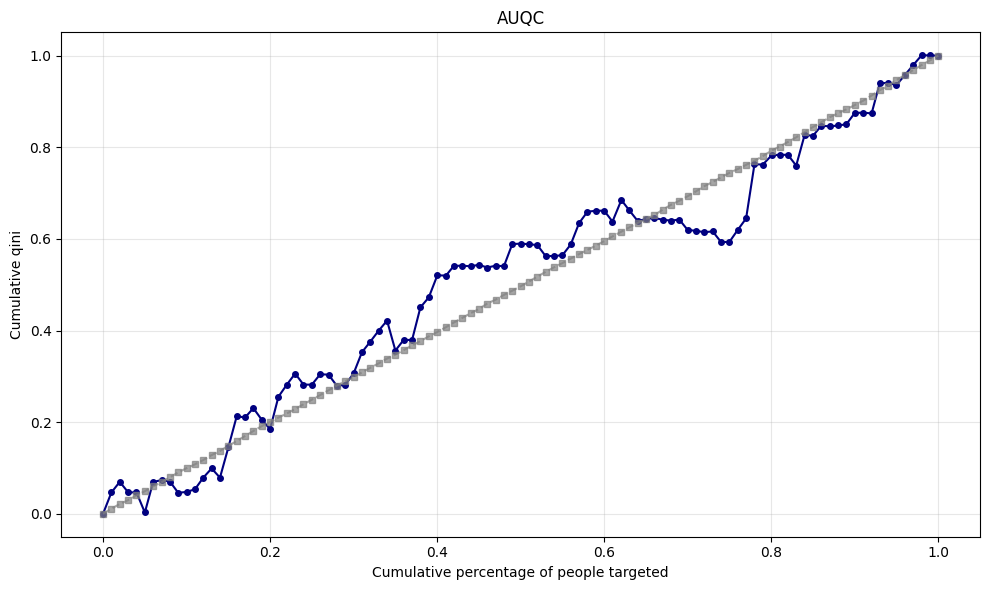

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.512
AUQC: 0.509
Lift: 0.007
KRCC: 0.021
ATE (predicted): 0.0065
ATE (true): 0.0067
ATE error: 0.0002


In [ ]:
seed = 1874 
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 1.2785 | Val Loss: 1.2086 | Val Qini: 0.2687 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2687 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 0.8468 | Val Loss: 0.6748 | Val Qini: 0.2673 (patience: 1/10)EMA Trend: 0.2685 | (patience: 1/10)
Epoch 3/50 | Loss: 0.2082 | Val Loss: 0.1376 | Val Qini: 0.7203 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3363 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/50 | Loss: 0.1543 | Val Loss: 0.1775 | Val Qini: 0.7038 ✓ above trend but not peak (patience: 1/10)EMA Trend: 0.3914 | ✓ above trend but not peak (patience: 1/10)
Epoch 5/50 | Loss: 0.1963 | Val Loss: 0.2041 | Val Qini: 0.3298 (patience: 2/10)EMA Trend: 0.3822 | (patience: 2/10)
Epoch 6/50 | Loss: 0.1619 | Val Loss: 0.

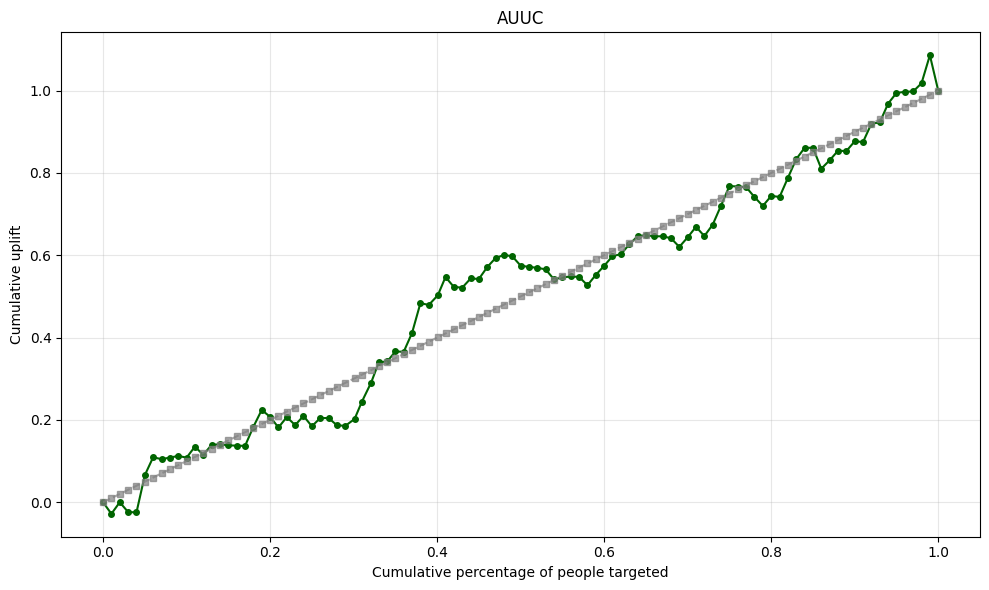

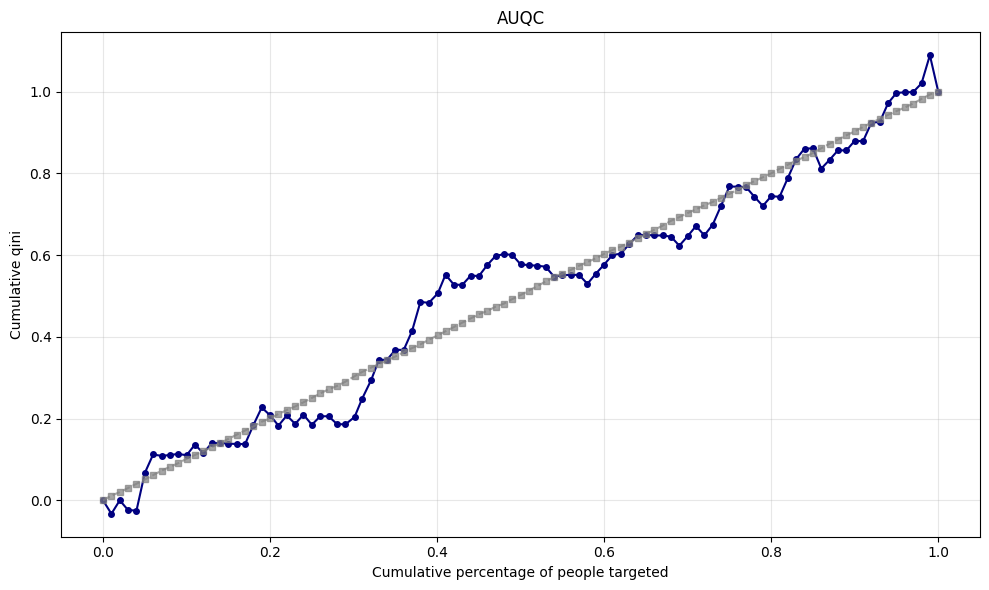

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.501
AUQC: 0.503
Lift: 0.005
KRCC: -0.074
ATE (predicted): -0.0307
ATE (true): 0.0067
ATE error: 0.0374


In [ ]:
seed = 902745
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 1.3081 | Val Loss: 1.2569 | Val Qini: 0.3482 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3482 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 0.9811 | Val Loss: 0.8310 | Val Qini: 0.7635 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.4105 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Loss: 0.2939 | Val Loss: 0.1827 | Val Qini: 0.5232 ✓ above trend but not peak (patience: 1/10)EMA Trend: 0.4274 | ✓ above trend but not peak (patience: 1/10)
Epoch 4/50 | Loss: 0.1528 | Val Loss: 0.1607 | Val Qini: 0.2609 (patience: 2/10)EMA Trend: 0.4024 | (patience: 2/10)
Epoch 5/50 | Loss: 0.2162 | Val Loss: 0.2198 | Val Qini: 0.2823 (patience: 3/10)EMA Trend: 0.3844 | (patience: 3/10)
Epoch 6/50 | Loss: 0.2608 | Val Loss: 0.1994 

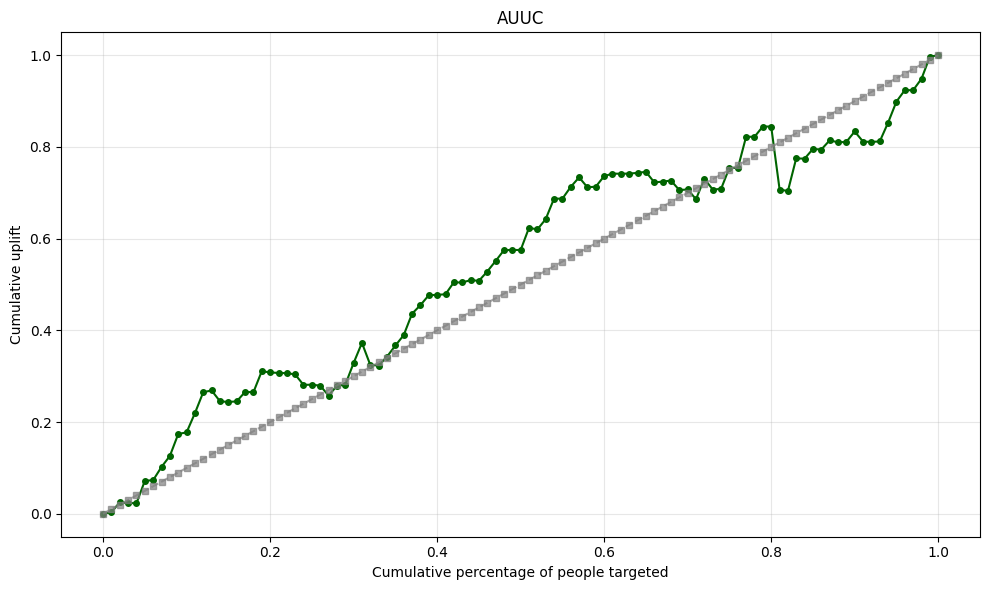

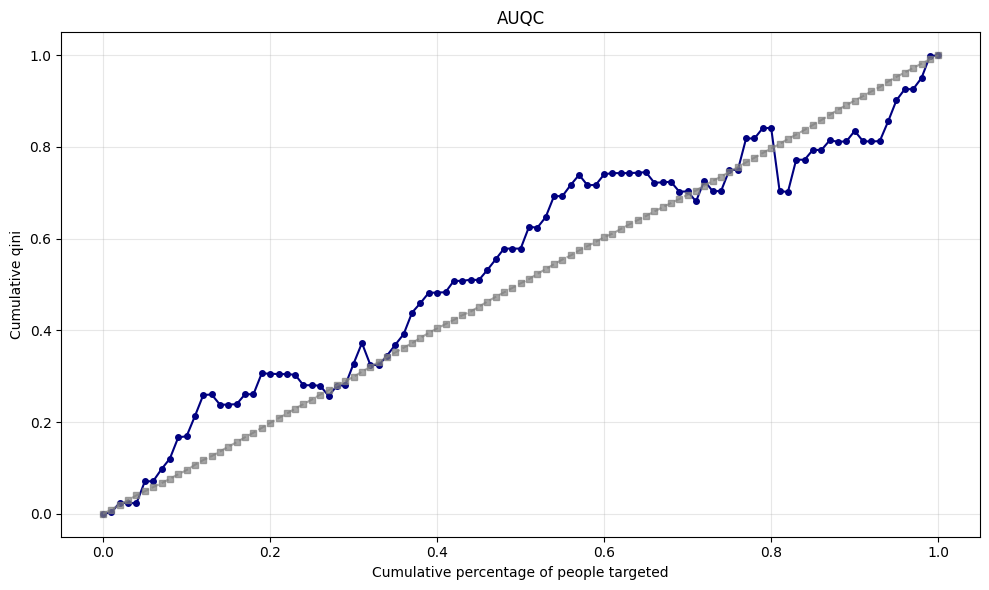

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.538
AUQC: 0.537
Lift: 0.007
KRCC: 0.043
ATE (predicted): -0.0059
ATE (true): 0.0067
ATE error: 0.0126


In [ ]:
seed = 1
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")